In [1]:
import sys
sys.path.append('../../../Share')
import config, baseline, Target, Model

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from collections import Counter

def balance_data(X, y):
    # Count samples per class
    class_counts = Counter(y)
    min_count = min(class_counts.values())  # target: balance all to minority count

    indices_list = []

    for label in sorted(class_counts.keys()):
        label_indices = np.where(y == label)[0]
        selected_indices = np.random.choice(label_indices, size=min_count, replace=False)
        indices_list.extend(selected_indices)

    # Shuffle all selected indices
    balanced_indices = np.random.permutation(indices_list)

    # Subset the data
    X_balanced = X[balanced_indices]
    y_balanced = y[balanced_indices]

    return X_balanced, y_balanced

In [2]:
SUBJECT = "Minjeong"
baseline_K_val = [i for i in range(len(config.dataset_sub_M))]

ACC_lst = []
for i, K in enumerate(baseline_K_val[1:-1]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, _, _ = trainer.return_until_K_data(K, train_ratio=1)
    X_train, y_train = balance_data(X_train, y_train)

    X_test, y_test, _, _ = trainer.return_K_th_data_only(K+1, train_ratio=1)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    #print(pd.Series(y_test).value_counts())

    history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='', set_verbose=False, save_model_set=False)
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    ACC_lst.append(acc)
    print(ACC_lst, f"{i}/{len(baseline_K_val)}\n\n")
    pd.DataFrame(history.history).to_csv(f'./Result/{SUBJECT}/train_with_{K}_test_with_next_session.csv', index=False)


Dataset 1/18 - Session Exp_2025-08-01-v1/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-08-02-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.5248538255691528] 0/18


Dataset 1/18 - Session Exp_2025-08-01-v1/E9AD0E7DCC2B/
Dataset 2/18 - Session Exp_2025-08-01-v2/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-08-02-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.5248538255691528, 0.5611110925674438] 1/18


Dataset 1/18 - Session Exp_2025-08-01-v1/E9AD0E7DCC2B/
Dataset 2/18 - Session Exp_2025-08-01-v2/E9AD0E7DCC2B/
Dataset 3/18 - Session Exp_2025-08-02-v1/E9AD0E7DCC2B/
Returning K-th session data: Exp_2025-08-09-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.5248538255691528, 0.5611110925674438, 0.5962121486663818] 2/18


Dataset 1/18 - Session Exp_2025-08-01-v1/E9AD0E7DCC2B/
Dataset 2/18 - Session Exp_2025-08-01-v2/E9AD0E7DCC2B/
Dataset 3/18 - Session Exp_2025-08-02-v1/E9AD0E7DCC2B/
Dataset 4/18 - Session Exp_2025-08-02-v2/E9AD0E7DCC2B/
Returning

In [3]:
ACC_lst_target = []
for i, K in enumerate(baseline_K_val[1:-1]):
    trainer = baseline.ModelTrainer(config, subject=f"{SUBJECT}")
    X_train, y_train, X_test, y_test = trainer.return_K_th_data_only(K, train_ratio=0.7)
    X_train, y_train = balance_data(X_train, y_train)
    X_test, y_test = balance_data(X_test, y_test)

    model = Model.Original_model(X_train.shape[1:], num_class=6)

    history, _ = Model.Train_model_without_test(model, X_train, y_train, set_epoch=100, set_batch_size=128, Model_name='', set_verbose=False, save_model_set=False)
    acc = model.evaluate(X_test, y_test, verbose=0)[1]
    ACC_lst_target.append(acc)
    print(ACC_lst_target, f"{i}/{len(baseline_K_val)}\n\n")
    #pd.DataFrame(history.history).to_csv(f'./Result/{SUBJECT}/train_with_{K}_test_with_next_session.csv', index=False)


Returning K-th session data: Exp_2025-08-01-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.7418699264526367] 0/18


Returning K-th session data: Exp_2025-08-02-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.7418699264526367, 0.7107843160629272] 1/18


Returning K-th session data: Exp_2025-08-02-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.7418699264526367, 0.7107843160629272, 0.5416666865348816] 2/18


Returning K-th session data: Exp_2025-08-09-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.7418699264526367, 0.7107843160629272, 0.5416666865348816, 0.4833333194255829] 3/18


Returning K-th session data: Exp_2025-08-09-v2/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.7418699264526367, 0.7107843160629272, 0.5416666865348816, 0.4833333194255829, 0.7083333134651184] 4/18


Returning K-th session data: Exp_2025-08-10-v1/E9AD0E7DCC2B/
Start Training (total epochs: 100)...
[0.7418699264526367, 0.7107843160629272, 0.5416666865348816, 0.483

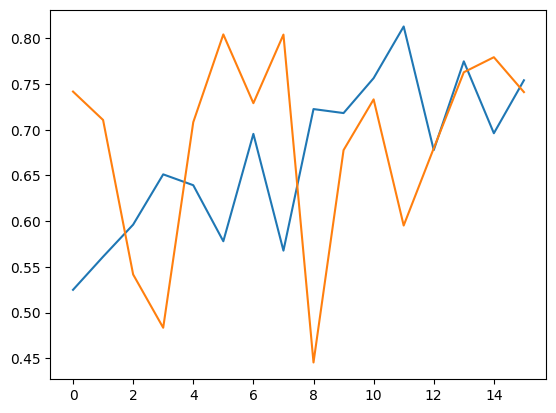

In [4]:
plt.plot(ACC_lst)
plt.plot(ACC_lst_target)
plt.show()

In [ ]:
[0.7418699264526367, 0.7107843160629272, 0.5416666865348816, 0.4833333194255829, 0.7083333134651184, 0.804444432258606, 0.7291666865348816, 0.8042327761650085, 0.4453125, 0.6777777671813965, 0.7333333492279053, 0.5952380895614624, 0.6798245906829834, 0.7630208134651184, 0.7794871926307678, 0.7412935495376587]